In [32]:
import pandas as pd
data = pd.read_csv('dataset\india_earthquakes.csv')

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer



X = data[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']]
y = data['mag']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest - MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R-squared: {r2}")


Random Forest - MAE: 0.2168163853727145, MSE: 0.08704434203234877, RMSE: 0.2950327812842986, R-squared: 0.5329488716134309


 Linear Regression Implementation

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer



X = data[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']]
y = data['mag']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression - MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R-squared: {r2}")


Linear Regression - MAE: 0.25272322349668125, MSE: 0.1191845818725728, RMSE: 0.34523120060703205, R-squared: 0.36049498278498837


XGBoost (Gradient Boosting) Implementation

In [35]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# data = pd.read_csv('india_earthquakes.csv')

X = data[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']]
y = data['mag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost - MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R-squared: {r2}")


XGBoost - MAE: 0.21672067036943937, MSE: 0.08609541932374092, RMSE: 0.29342020946714104, R-squared: 0.5380404767822335


Support Vector Regression (SVR) Implementation

In [36]:

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# data = pd.read_csv('india_earthquakes.csv')

X = data[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']]
y = data['mag']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"SVR - MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R-squared: {r2}")


SVR - MAE: 0.22227283358105662, MSE: 0.09517184078172015, RMSE: 0.3084993367605839, R-squared: 0.4893394034593306


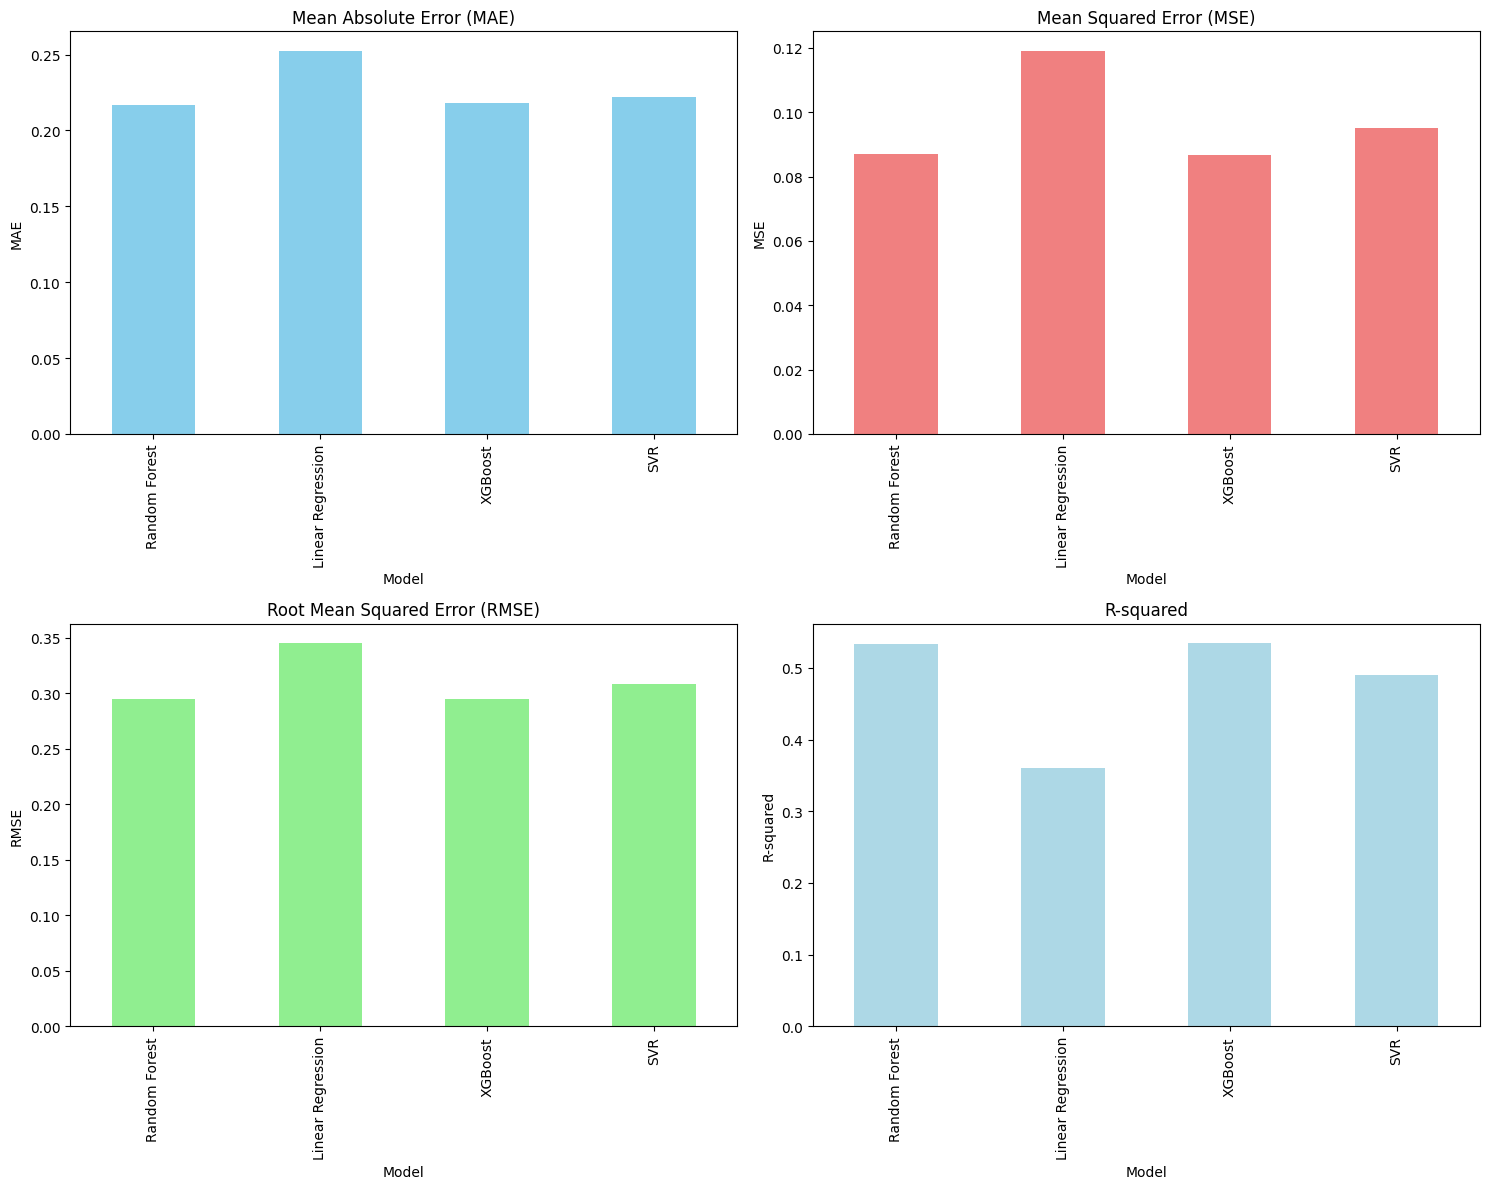

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# data = pd.read_csv('india_earthquakes.csv')

X = data[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']]
y = data['mag']

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

metrics = {
    'Model': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R-squared': []
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for model_name, model in models.items():
    if model_name == 'SVR':
        X_train_model, X_test_model = X_train_scaled, X_test_scaled
    else:
        X_train_model, X_test_model = X_train, X_test

    model.fit(X_train_model, y_train)

    y_pred = model.predict(X_test_model)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    metrics['Model'].append(model_name)
    metrics['MAE'].append(mae)
    metrics['MSE'].append(mse)
    metrics['RMSE'].append(rmse)
    metrics['R-squared'].append(r2)

metrics_df = pd.DataFrame(metrics)

fig, ax = plt.subplots(2, 2, figsize=(15, 12))

metrics_df.plot(kind='bar', x='Model', y='MAE', ax=ax[0, 0], color='skyblue', legend=False)
ax[0, 0].set_title('Mean Absolute Error (MAE)')
ax[0, 0].set_ylabel('MAE')

metrics_df.plot(kind='bar', x='Model', y='MSE', ax=ax[0, 1], color='lightcoral', legend=False)
ax[0, 1].set_title('Mean Squared Error (MSE)')
ax[0, 1].set_ylabel('MSE')

metrics_df.plot(kind='bar', x='Model', y='RMSE', ax=ax[1, 0], color='lightgreen', legend=False)
ax[1, 0].set_title('Root Mean Squared Error (RMSE)')
ax[1, 0].set_ylabel('RMSE')

metrics_df.plot(kind='bar', x='Model', y='R-squared', ax=ax[1, 1], color='lightblue', legend=False)
ax[1, 1].set_title('R-squared')
ax[1, 1].set_ylabel('R-squared')

plt.tight_layout()
plt.show()


In [38]:


#@title Input Earthquake Data
latitude = 19.0911 #@param {type:"number"}
longitude = 72.5235 #@param {type:"number"}
depth = 10 #@param {type:"number"}
nst = 70 #@param {type:"number"}
gap = 65 #@param {type:"number"}
dmin = 4.14 #@param {type:"number"}
rms = 0.8 #@param {type:"number"}


new_data = [[latitude, longitude, depth, nst, gap, dmin, rms]]
new_data_transformed = imputer.transform(new_data)
predicted_magnitude = model.predict(new_data_transformed)
print(f"Predicted Earthquake Magnitu1de (Random Forest): {predicted_magnitude[0]}")

Predicted Earthquake Magnitu1de (Random Forest): 4.721412991652754


c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('dataset\india_earthquakes.csv')

df = df.dropna()

df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['minute'] = df['time'].dt.minute
df['second'] = df['time'].dt.second

X = df[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms', 'horizontalError',
        'depthError', 'magError', 'year', 'month', 'day', 'hour', 'minute', 'second']]

y = df['mag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)
1

best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30, 'bootstrap': True}
Mean Squared Error: 0.04081827612154368
R-squared: 0.7265273840805941


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# df = pd.read_csv('/content/india_earthquakes.csv')

df = df[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms', 'magNst', 'mag']].dropna()

X = df[['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms', 'magNst']]
y = df['mag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=20, cv=3, verbose=1, random_state=42, n_jobs=-1)


random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
Mean Squared Error: 0.03611748719847255
Root Mean Squared Error: 0.19004601337168994
Mean Absolute Error: 0.14317485786304684
R-squared: 0.7580215373331547


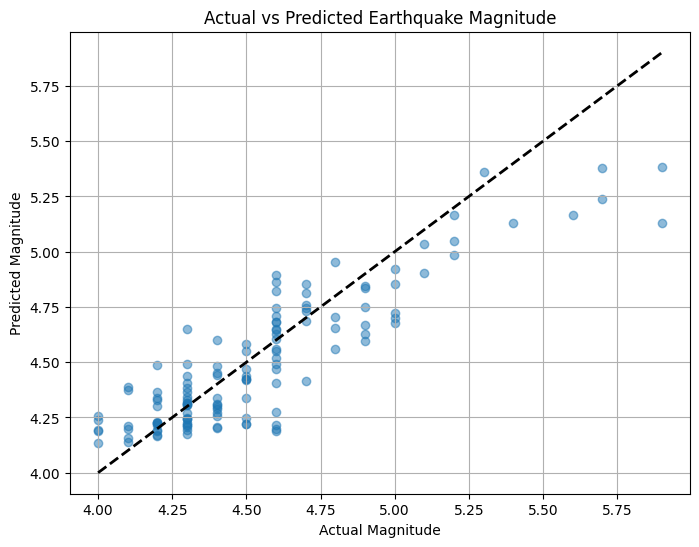

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs Predicted Earthquake Magnitude')
plt.grid(True)
plt.show()

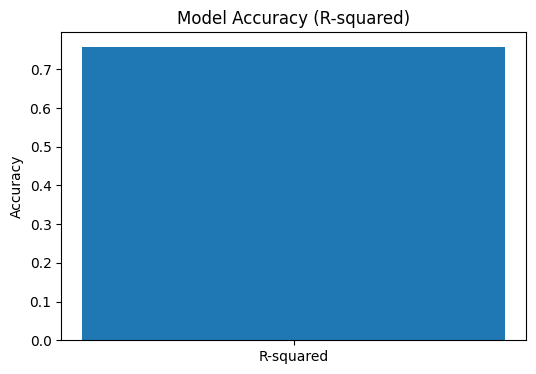

In [43]:
plt.figure(figsize=(6, 4))
plt.bar(['R-squared'], [r2])
plt.ylabel('Accuracy')
plt.title('Model Accuracy (R-squared)')
plt.show()

In [44]:
#@title Input Earthquake Data
latitude = 19.0911 #@param {type:"number"}
longitude = 72.5535 #@param {type:"number"}
depth = 10 #@param {type:"number"}
nst = 70 #@param {type:"number"}
gap = 65 #@param {type:"number"}
dmin = 4.14 #@param {type:"number"}
rms = 0.8 #@param {type:"number"}
magNst = 5.2 #@param {type:"number"}

new_data = [[latitude, longitude, depth, nst, gap, dmin, rms, magNst]]
predicted_magnitude = best_model.predict(new_data)
print(f"Predicted Earthquake Magnitude (Random Forest): {predicted_magnitude[0]}")

Predicted Earthquake Magnitude (Random Forest): 5.003109126984126


c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [47]:
import joblib

# Assuming 'model' is your trained model
joblib.dump(best_model, 'earthquake_model.pkl')

print("Earthquake model saved successfully!")


Earthquake model saved successfully!


In [46]:
print(best_model)


RandomForestRegressor(max_depth=20, min_samples_split=5)
